# PCA Assignments
Step-by-step notebook with explanations.

## Step 1: Load Dataset and Prepare Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("manufacturing_6G_dataset.csv")

# Keep numeric columns
df = df.select_dtypes(include=[np.number]).dropna()
df.head()

,Machine_ID,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
0,39,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470
1,29,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270
2,15,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391
3,43,40.568502,0.298238,4.067825,29.153629,1.161021,4.582974,329.579410,0.983390,2.740847
4,8,75.063817,0.345810,6.225737,34.029191,4.796520,2.287716,159.113525,0.573117,12.100686


## Assignment 1: Projection Geometry
We project data onto a manually chosen direction.

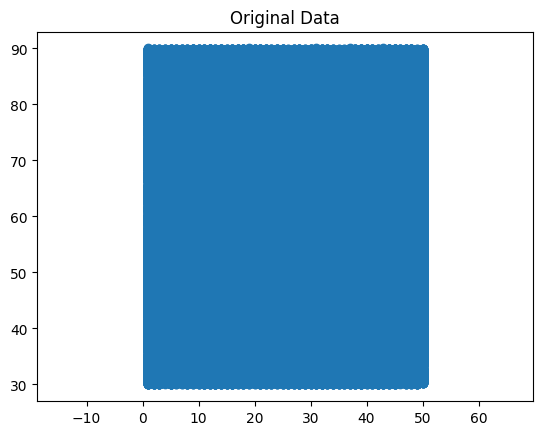

Original variance: 507.1454376990025
Projected variance: 254.11159370058374


In [3]:
X = df.iloc[:, :2].values

plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.axis('equal')
plt.show()

v = np.array([1,1])
v = v / np.linalg.norm(v)

z = X @ v
X_proj = np.outer(z, v)

print("Original variance:", np.var(X, axis=0).sum())
print("Projected variance:", np.var(z))

## Assignment 2: Eigenvalues and Eigenvectors

In [4]:
cov_matrix = np.cov(X, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [207.05282902 300.09768019]
Eigenvectors:
 [[-0.99998323 -0.00579172]
 [ 0.00579172 -0.99998323]]


## Assignment 3: PCA from Scratch

In [5]:
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

cov = np.cov(X_std, rowvar=False)
eig_vals, eig_vecs = np.linalg.eig(cov)

idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

W = eig_vecs[:, :1]
Z = X_std @ W

print("Top eigenvalue:", eig_vals[0])

Top eigenvalue: 1.0021718407730655


## Assignment 4: PCA as Rotation

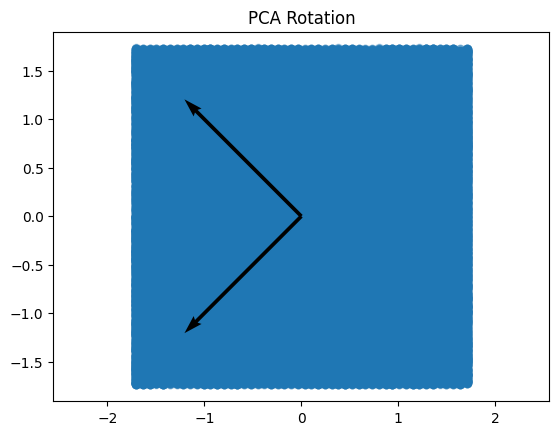

In [6]:
plt.scatter(X_std[:,0], X_std[:,1], alpha=0.3)

origin = [0,0]
plt.quiver(*origin, eig_vecs[0,0], eig_vecs[1,0], scale=3)
plt.quiver(*origin, eig_vecs[0,1], eig_vecs[1,1], scale=3)

plt.title("PCA Rotation")
plt.axis('equal')
plt.show()

## Assignment 5: Reconstruction Error

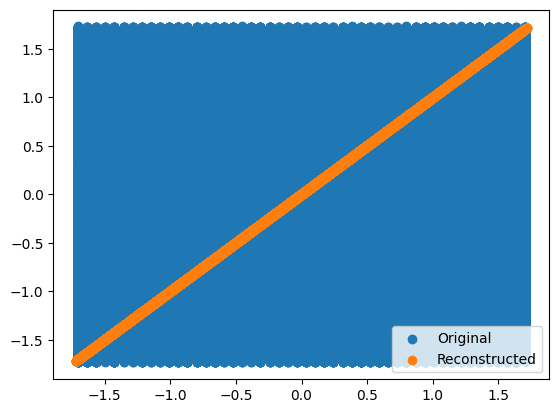

Reconstruction error: 0.49891909047267113


In [7]:
X_recon = Z @ W.T

plt.scatter(X_std[:,0], X_std[:,1], label="Original")
plt.scatter(X_recon[:,0], X_recon[:,1], label="Reconstructed")
plt.legend()
plt.show()

error = np.mean((X_std - X_recon)**2)
print("Reconstruction error:", error)

## Assignment 6: Effect of Scaling

In [8]:
cov_unscaled = np.cov(X, rowvar=False)
cov_scaled = np.cov(X_std, rowvar=False)

print("Unscaled eigenvalues:", np.linalg.eig(cov_unscaled)[0])
print("Scaled eigenvalues:", np.linalg.eig(cov_scaled)[0])

Unscaled eigenvalues: [207.05282902 300.09768019]
Scaled eigenvalues: [0.99784816 1.00217184]


## Assignment 7: Explained Variance

In [9]:
total = np.sum(eig_vals)
ratio = eig_vals / total

print("Explained variance ratio:", ratio)

Explained variance ratio: [0.50108091 0.49891909]


## Assignment 8: PCA on 3D Data (if available)

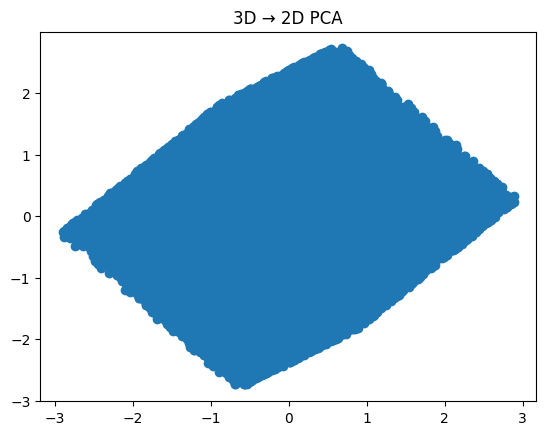

In [10]:
if df.shape[1] >= 3:
    X3 = df.iloc[:, :3].values
    X3 = (X3 - X3.mean(axis=0)) / X3.std(axis=0)

    cov3 = np.cov(X3, rowvar=False)
    eig_vals3, eig_vecs3 = np.linalg.eig(cov3)

    W3 = eig_vecs3[:, :2]
    Z3 = X3 @ W3

    plt.scatter(Z3[:,0], Z3[:,1])
    plt.title("3D → 2D PCA")
    plt.show()

## Assignment 9: Compression

In [11]:
original_size = X_std.size
reduced_size = Z.size

print("Original size:", original_size)
print("Reduced size:", reduced_size)
print("Compression ratio:", reduced_size/original_size)

Original size: 200000
Reduced size: 100000
Compression ratio: 0.5


## Final Insight
• What does PCA optimize mathematically?
Maximizes variance of projected data (equivalently minimizes reconstruction error).

• Why is variance used as a measure of “information”?
Higher variance = more spread = more distinguishing signal between data points.

• What happens if features are not correlated — is PCA useful?
Not very useful; it won’t reduce dimensions effectively.

• Why do we standardize data before applying PCA?
To prevent large-scale features from dominating variance.

• What is the difference between covariance and correlation in PCA context?
Covariance depends on scale; correlation is scale-normalized.
• How is PCA related to projection of data onto a new axis?
It projects data onto directions (principal components) that maximize variance.

• Why are principal components orthogonal to each other?
To ensure no redundancy (uncorrelated components).

• What does it mean to “rotate the coordinate system” in PCA?
Changing axes to align with directions of maximum variance.

• How does PCA reduce redundancy in features?
By combining correlated features into fewer uncorrelated components.

• Can principal components always be interpreted easily? Why or why not?
No; they are linear combinations, often hard to interpret.

• What does a negative loading in a principal component indicate?
Inverse relationship with that feature.

• If two features are highly correlated, how will PCA treat them?
Combine them into one principal component.

• What does it mean if the first principal component explains 90% variance?
Most information lies in a single direction.
• Does PCA use output labels? What is the implication?
No; it’s unsupervised → may ignore class separation.

• When should PCA be avoided even if dimensionality is high?
When interpretability or label information is critical.

• How does PCA affect model interpretability?
Reduces it, since features become abstract combinations.

• Can PCA improve model performance always? Why not?
No; it may remove useful information for prediction.

• What happens if all features have equal variance and no correlation?
PCA gives no meaningful dimensionality reduction.

• What if one feature has extremely large scale compared to others?
It dominates PCA unless data is standardized.

• Can PCA capture nonlinear relationships? Why or why not?
No; it is a linear method.

• Why might PCA fail in classification problems?
Maximizes variance, not class separability.